# Gradient dispersion showcase

This notebook mirrors the paper's showcase section end to end. It starts from a
chamber-scale electric field with genuine spatial structure: two asymmetric
electrode plates plus a patch-potential wall spot, solved from scratch by
finite differences in `examples/generate_showcase_field.py`, with no COMSOL or
other paid software involved. That field is propagated through a classical
Monte Carlo Sr-87 ensemble whose cloud size is deliberately scaled to sample
the field's structure. The result is reported as a full **inhomogeneous shift
budget**: mean shift, ensemble spread, dephasing time `T2*`, and spectral line
profile. The budget is cross-checked between the pipeline's **trajectory mode**
(a real Monte Carlo ensemble's classical trajectories through the field) and
its **rotor mode** (the general Cl(1,3) spacetime-algebra engine), run on the
*identical* trajectories.

The scale is anchored to a documented class of real events. Lodewyck et al.
observed and then cancelled a stray-charge DC-Stark shift at an operating Sr
lattice clock (IEEE TUFFC 59, 411 (2012), arXiv:1108.4320). A field event of
this scenario's magnitude would dominate a clock's coherence outright. Read it
as the two questions a practitioner would bring: what signature a charge-patch
event leaves on an operating clock's shift, spread, and `T2*`, and what
stray-field level a chamber geometry under design can tolerate before it
matters.

**Status: pre-validation research code**, same caveat as every other notebook
here (see the top-level README's Status section).

**MEMORY-SAFETY NOTE (binding).** This notebook reuses the exact,
already-measured-safe scenario parameters from
`examples/showcase_gradient_dispersion_sr87.yaml`: a fixed `ensemble.size=100`
and an explicit `integration.dtau` with `steps=318`. See that file's own
memory-safety note for why those two settings are pinned. An earlier,
unmonitored exploratory run used a larger ensemble size with
`integration.time_s` and an auto-selected `dtau`. That run drove memory usage
past 100 GB and hung the development machine. **Do not increase `ensemble.size`
or `integration.steps` in this notebook, and do not switch to
`integration.time_s`,** without first re-measuring peak RSS in a fresh
subprocess. See `paper/figures/fig4_showcase_gradient_dispersion.py`'s module
docstring for the measurement methodology and the compute-budget bounds. This
project also enforces those bounds with an executable guard in code.

In [1]:
%matplotlib inline
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This notebook runs with its working directory at notebooks/ (nbconvert's
# default); every path below is relative to that, matching notebook
# 01/03/04's convention.
EXAMPLES_DIR = Path("..") / "examples"
sys.path.insert(0, str(EXAMPLES_DIR.resolve()))
import generate_showcase_field as showcase_gen  # noqa: E402

from cliffordclock.analytics import build_report, coherence_function, line_profile  # noqa: E402
from cliffordclock.constants import BOLTZMANN_K  # noqa: E402
from cliffordclock.ensemble.species import get_species  # noqa: E402
from cliffordclock.pipeline import (  # noqa: E402
    PipelineConfig,
    _auto_renorm_every,
    _build_field_fn,
    _resolve_stark_coupling,
    _stark_rotor_ensemble,
    run_pipeline_full,
)

np.set_printoptions(precision=6, suppress=False)

## 1. The field: two asymmetric electrodes + a patch-potential spot

A simple parallel-plate capacitor is nearly linear across any small interior
region. This scenario is built specifically to avoid that: two electrode plates
of *different* size and voltage sit at non-mirror-symmetric positions, plus a
small circular patch-potential spot is embedded in one wall, a crude but
standard model of trapped-charge contamination. Together these carry real
curvature and cross-terms. `examples/generate_showcase_field.py` solves
Laplace's equation for this geometry from scratch, using NumPy and
`scipy.sparse` with a Jacobi-preconditioned conjugate gradient solver only. No
dense solve and no COMSOL are involved. `examples/showcase_field.txt` is the
committed, exported field the pipeline loads: a small interior sub-cube,
strictly clear of every electrode/patch boundary. See that script's module
docstring for the full geometry and the memory-safety bounds on its own solve
grid and export point count.

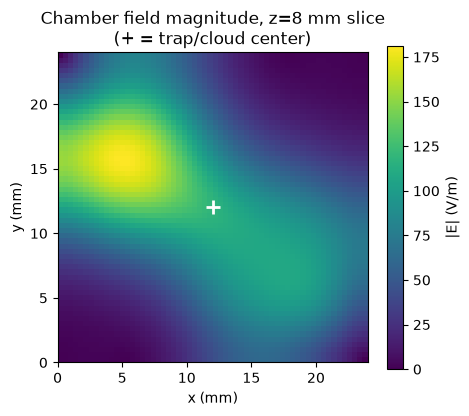

Electrode A: 3.0 V at z=3 mm
Electrode B: -1.2 V at z=13 mm
Patch spot:  4.5 V at z=0 (chamber wall)


In [2]:
v_grid = showcase_gen.solve_potential()
ex, ey, ez = showcase_gen.field_from_potential(v_grid)
e_mag_full = np.sqrt(ex**2 + ey**2 + ez**2)

cx, cy, cz = showcase_gen.TRAP_CENTER_M
kc = round(cz / showcase_gen.H_M)
extent_mm = [0.0, showcase_gen.BOX_X_M * 1e3, 0.0, showcase_gen.BOX_Y_M * 1e3]

fig, ax = plt.subplots(figsize=(5.0, 4.2))
im = ax.imshow(e_mag_full[:, :, kc].T, origin="lower", extent=extent_mm, cmap="viridis")
fig.colorbar(im, ax=ax, label="|E| (V/m)")
ax.plot([cx * 1e3], [cy * 1e3], marker="+", color="white", markersize=10, mew=2)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title(f"Chamber field magnitude, z={cz * 1e3:.0f} mm slice\n(+ = trap/cloud center)")
plt.show()

az_mm = showcase_gen.PLATE_A_Z_M * 1e3
bz_mm = showcase_gen.PLATE_B_Z_M * 1e3
print(f"Electrode A: {showcase_gen.PLATE_A_VOLTAGE_V} V at z={az_mm:.0f} mm")
print(f"Electrode B: {showcase_gen.PLATE_B_VOLTAGE_V} V at z={bz_mm:.0f} mm")
print(f"Patch spot:  {showcase_gen.PATCH_VOLTAGE_V} V at z=0 (chamber wall)")

## 2. Why the cloud is chamber-scale

A real optical-lattice-site cloud's motional ground-state extent is tens of
nanometers (`docs/timescales.md`), far smaller than any chamber-scale field
feature, so it would never sample genuine field curvature. This showcase uses a
classical, chamber-scale trapping stage instead (a large-volume "science"
dipole/magnetic trap) with a trap frequency and temperature chosen so the
classical thermal cloud size is a meaningful fraction of the field's own
spatial-variation scale. That is a scenario-*geometry* choice (trap frequency,
temperature), documented as such; no physical constant is touched to reach it.

In [3]:
config = PipelineConfig.from_yaml(EXAMPLES_DIR / "showcase_gradient_dispersion_sr87.yaml")
# Path fix-up only (the shipped YAML's field.comsol path assumes repo-root
# invocation; this notebook's cwd is notebooks/) -- every physics
# parameter (species, trap, temperature, ensemble.size, integration.dtau/
# steps) is unchanged from the shipped, memory-safety-checked config.
config = replace(
    config,
    field_config=replace(
        config.field_config, comsol_path=str((EXAMPLES_DIR / "showcase_field.txt").resolve())
    ),
)
assert config.integration.dtau is not None and config.integration.steps is not None, (
    "showcase config must pin integration.dtau/steps explicitly -- see the memory-safety note"
)

species = get_species(config.species)
trap_omega = float(np.asarray(config.trap.omega_xyz)[0])
cloud_sigma_m = np.sqrt(
    BOLTZMANN_K * config.ensemble.temperature_uK * 1e-6 / (species.mass_kg * trap_omega**2)
)
print(f"trap: {trap_omega:.0f} rad/s isotropic, T={config.ensemble.temperature_uK:.0f} uK")
print(f"cloud sigma = sqrt(kB*T/(m*omega^2)) = {cloud_sigma_m * 1e6:.0f} um")
print(f"ensemble size: {config.ensemble.size} classical Monte Carlo atoms")
print(f"field export half-extent: {showcase_gen.EXPORT_HALF_EXTENT_M * 1e3:.2f} mm")

trap: 100 rad/s isotropic, T=50 uK
cloud sigma = sqrt(kB*T/(m*omega^2)) = 692 um
ensemble size: 100 classical Monte Carlo atoms
field export half-extent: 3.28 mm


## 3. Run the pipeline: trajectory mode

Each atom's classical trajectory (Maxwell-Boltzmann velocities, velocity-Verlet
propagation in the trap) is propagated through the fitted field and accumulates
its DC-Stark phase via the pipeline's **trajectory mode** (`ensemble.regime:
classical`, `integration.mode: direct`, the default there). That is what
`cliffordclock run examples/showcase_gradient_dispersion_sr87.yaml` would do
from the repo root.

In [4]:
result = run_pipeline_full(config)
report_scalar = result.report

print(f"ensemble_type: {report_scalar.ensemble_type}")
print(f"interrogation_time_s: {report_scalar.interrogation_time_s:.6f}")
print(
    f"mean_fractional_shift: {report_scalar.mean_fractional_shift:+.6e} "
    f"+/- {report_scalar.shift_std_error:.3e} (SEM)"
)
print(f"t2_star_s: {report_scalar.t2_star_s:.6e} s")

ensemble_type: classical_direct
interrogation_time_s: 0.199805
mean_fractional_shift: -9.965267e-17 +/- 6.514e-19 (SEM)
t2_star_s: 2.796688e-04 s


## 4. Cross-check: the identical trajectories through the rotor mode

The pipeline's `integration.mode=worldline` keyword only exposes the
Cl(1,3) rotor cross-check for static lattice nodes in the shipped config
schema: a moving classical trajectory (what trajectory mode just
produced) is not reachable through `integration.mode` alone. The
underlying accumulator (`cliffordclock.pipeline._stark_rotor_ensemble`,
the same function `integration.mode=worldline` calls for
`coupling.type=stark_dc`) places no such restriction, so it is driven
directly here, on the *exact* trajectories `result.trajectories` just
produced. That shared input is what makes the agreement below a genuine
cross-check of the two accumulators: both operate on one identical
Monte Carlo draw, so any difference in the result traces to the
accumulator math alone.


In [5]:
stark_coeffs = _resolve_stark_coupling(config.coupling, species)
field_fn, _n_fit_points = _build_field_fn(config.field_config)
ensemble_result_rotor = _stark_rotor_ensemble(
    field_fn,
    stark_coeffs,
    result.trajectories,
    config.integration.dtau,
    renorm_every=_auto_renorm_every(),
)
report_rotor = build_report(
    ensemble_result_rotor.phase,
    species,
    report_scalar.interrogation_time_s,
    "classical_direct_rotor_crosscheck",
)

phase_scalar = np.asarray(result.ensemble_result.phase)
phase_rotor = np.asarray(ensemble_result_rotor.phase)
max_abs_phase_diff = float(np.max(np.abs(phase_scalar - phase_rotor)))
mean_shift_rel_diff = abs(
    report_scalar.mean_fractional_shift - report_rotor.mean_fractional_shift
) / abs(report_scalar.mean_fractional_shift)

print(
    f"trajectory mode: mean={report_scalar.mean_fractional_shift:+.6e}  "
    f"t2*={report_scalar.t2_star_s:.6e} s"
)
print(
    f"rotor mode:      mean={report_rotor.mean_fractional_shift:+.6e}  "
    f"t2*={report_rotor.t2_star_s:.6e} s"
)
print(f"mean-shift relative difference: {mean_shift_rel_diff:.3e}")
print(f"max per-atom |phase| difference (absolute): {max_abs_phase_diff:.3e}")

trajectory mode: mean=-9.965267e-17  t2*=2.796688e-04 s
rotor mode:      mean=-9.965267e-17  t2*=2.796688e-04 s
mean-shift relative difference: 0.000e+00
max per-atom |phase| difference (absolute): 2.910e-11


**The two evaluations agree to float64-noise precision.** Both modes compute
the same number, on this exact Monte Carlo ensemble, through two independent
accumulators: trajectory mode integrates the real classical trajectories
directly, and rotor mode evaluates the same physics through the general Cl(1,3)
engine. Neither is an approximation of the other; the agreement here is a
genuine cross-check of both.

## 5. The inhomogeneous shift budget

The reported spread across the ensemble is the physically meaningful dispersion
quantity here, distinct from the SEM on the mean: it is what sets the
inhomogeneous dephasing time `T2*` via the standard Gaussian-dephasing form
`T2* = sqrt(2) * T / sigma_Phi` (E27, CONVENTIONS.md). This is the quantity a
field-gradient map and a hand or spreadsheet mean-shift calculation does not
hand a lab.

The two panels below occupy very different frequency scales. The histogram
resolves the per-atom shift structure at the 1e-18 level. The line profile's
width is set by dephasing over the interrogation window instead, about
`1/(pi*T2*)`, roughly 1 kHz here, i.e. the 1e-12 fractional scale, so the mean
shift sits far below the line profile's resolution. That contrast is the point:
the line you would measure is orders of magnitude wider than the shift budget
hiding inside it.

mean fractional shift: -9.965267e-17
ensemble spread (population std): 6.5135e-18
SEM: 6.5135e-19
T2* = 279.7 us  (interrogation window: 199805 us)


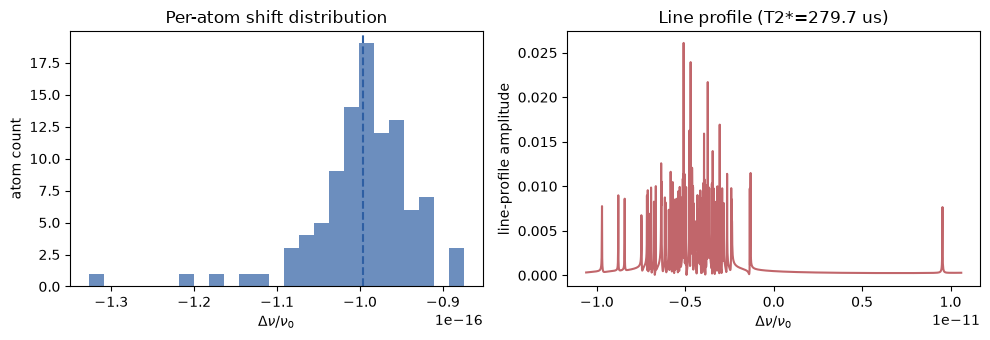

In [6]:
shift_scalar = np.asarray(result.ensemble_result.fractional_shift)
shift_rotor = np.asarray(ensemble_result_rotor.fractional_shift)
shift_spread = float(np.std(shift_scalar, ddof=1))

print(f"mean fractional shift: {report_scalar.mean_fractional_shift:+.6e}")
print(f"ensemble spread (population std): {shift_spread:.4e}")
print(f"SEM: {report_scalar.shift_std_error:.4e}")
interrogation_us = report_scalar.interrogation_time_s * 1e6
t2_star_us = report_scalar.t2_star_s * 1e6
print(f"T2* = {t2_star_us:.1f} us  (interrogation window: {interrogation_us:.0f} us)")

n_time_samples = config.output.n_time_samples
dt_s = report_scalar.interrogation_time_s / (n_time_samples - 1)
t_grid_s = np.arange(n_time_samples, dtype=np.float64) * dt_s
coherence = coherence_function(
    result.ensemble_result.phase, report_scalar.interrogation_time_s, t_grid_s
)
freqs_hz, amplitude = line_profile(coherence, dt_s)
freq_shift_units = freqs_hz / species.clock_frequency_hz

fig, (ax_hist, ax_line) = plt.subplots(1, 2, figsize=(10, 3.5))
ax_hist.hist(shift_scalar, bins=25, color="#2E5FA3", alpha=0.7)
ax_hist.axvline(report_scalar.mean_fractional_shift, color="#2E5FA3", ls="--")
ax_hist.set_xlabel(r"$\Delta\nu/\nu_0$")
ax_hist.set_ylabel("atom count")
ax_hist.set_title("Per-atom shift distribution")

# Window the line plot by the line's own dephasing width, not the shift
# spread: the FFT bin spacing is 1/T (~1.2e-14 fractional here), four
# orders of magnitude coarser than the 6.5e-18 ensemble spread, so a
# spread-sized window would select no frequency bin at all.
linewidth_fractional = 1.0 / (np.pi * report_scalar.t2_star_s * species.clock_frequency_hz)
half_window = 4.0 * linewidth_fractional
mask = np.abs(freq_shift_units - report_scalar.mean_fractional_shift) < half_window
ax_line.plot(freq_shift_units[mask], amplitude[mask], color="#C1666B")
ax_line.set_xlabel(r"$\Delta\nu/\nu_0$")
ax_line.set_ylabel("line-profile amplitude")
ax_line.set_title(f"Line profile (T2*={report_scalar.t2_star_s * 1e6:.1f} us)")
fig.tight_layout()
plt.show()

## Where to go next

- `paper/main.tex`'s "Showcase" section: the same computation, written
  up as part of the paper's narrative.
- `paper/figures/fig4_showcase_gradient_dispersion.py`: the script
  that regenerates the paper's Figure 4 and every quoted number in the
  showcase section, from this exact scenario.
- `examples/generate_showcase_field.py`: the field generator's full
  module docstring: geometry, back-of-envelope scale check, and the
  memory-safety bounds this project now enforces on its own solve grid
  and export point count.
- `examples/showcase_gradient_dispersion_sr87.yaml`: the runnable
  config (`cliffordclock run examples/showcase_gradient_dispersion_sr87.yaml`
  from the repo root), including its own memory-safety note.
- `docs/timescales.md`: the three evaluation modes (fast analytic,
  trajectory, rotor) and their performance tiers.
- `notebooks/04_bring_your_own_field.ipynb`: the lattice-regime
  "bring your own field" adaptation template (fast analytic mode, a
  spatially uniform-at-the-motional-scale field); this notebook is the
  classical-regime, spatially-varying counterpart.
